# IQR removal of outliers

- used for skewed distributions
- Calculate upper and lower limits as :
    - min - Q1 - 1.5IQR
    - max - Q3 + 1.5IQR
    - iqr = Q3 - Q1
    - Q1 - $25^{th}$ %ile
    - Q3 - $75^{th}$ %ile

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# I got the dataset with the outliers muahahaha
df = pd.read_csv('../datasets/placement_new.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
496,7.52,35.0,1
298,6.16,48.0,0
778,6.98,34.0,0
929,6.89,25.0,0
265,6.94,57.0,0


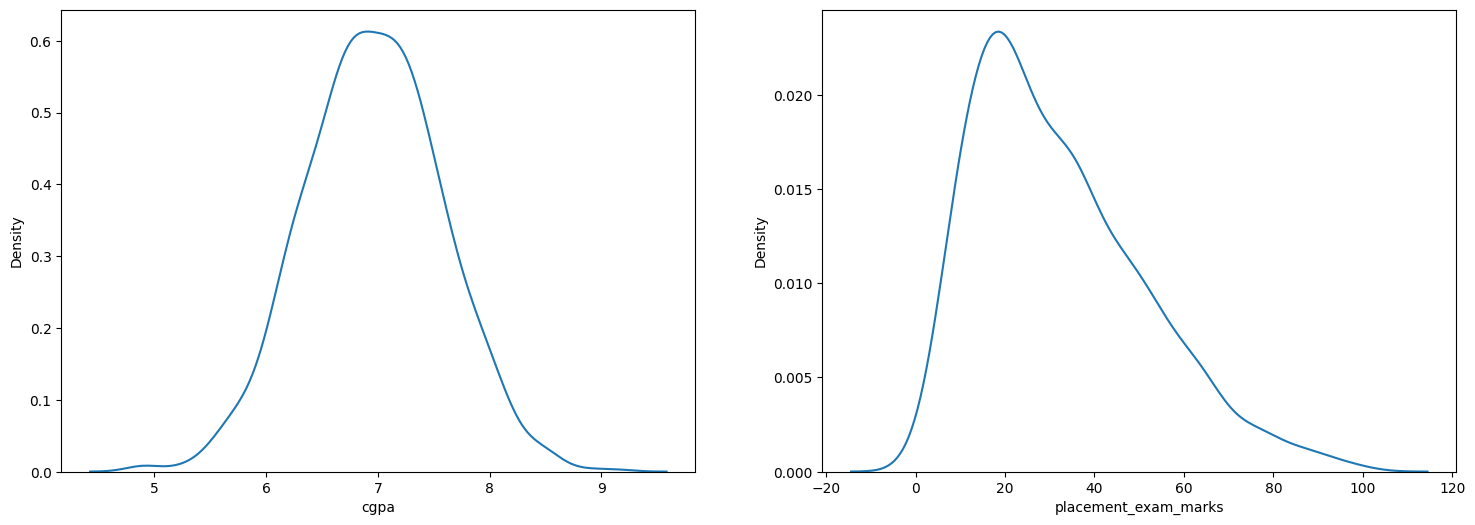

In [6]:
plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'])

plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'])

plt.show()

We can see that placement marks col is a little skewed -> detect using iqr and visulaize using boxplot

<Axes: ylabel='placement_exam_marks'>

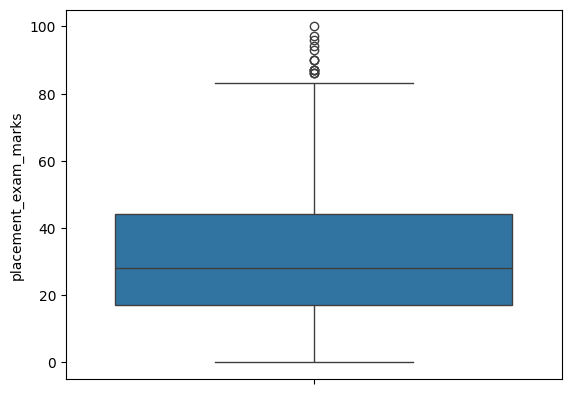

In [7]:
# Boxplot
sns.boxplot(df['placement_exam_marks'])

We can see a few outliers on the higher side of the data 

In [8]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [12]:
# Finding the percentiles and other required vals
q1 = df['placement_exam_marks'].quantile(0.25)
q3 = df['placement_exam_marks'].quantile(0.75)

iqr = q3 - q1

upper_limit = q3 + 1.5*iqr
lower_limit = q1 - 1.5*iqr

In [15]:
# Finding the outliers
outliers = df[(df['placement_exam_marks'] > upper_limit) | (df['placement_exam_marks'] < lower_limit)]
print(outliers)
outliers.count()

     cgpa  placement_exam_marks  placed
9    7.75                  94.0       1
40   6.60                  86.0       1
61   7.51                  86.0       0
134  6.33                  93.0       0
162  7.80                  90.0       0
283  7.09                  87.0       0
290  8.38                  87.0       0
311  6.97                  87.0       1
324  6.64                  90.0       0
630  6.56                  96.0       1
685  6.05                  87.0       1
730  6.14                  90.0       1
771  7.31                  86.0       1
846  6.99                  97.0       0
917  5.95                 100.0       0


cgpa                    15
placement_exam_marks    15
placed                  15
dtype: int64

We have 15 outliers and all are the ones that are above the higher limit and there are none which are below the lower val

Now trim or cap as in zscore 